# Buy after earnings?

This notebook looks at what happens after large earnings reactions in current Nasdaq-100 stocks. The primary signal is the stock's earnings-window return relative to SPY, and all forward returns start only after the reaction is observable.

The September 2026 run included **4,423 earnings events across 100 tickers** from 2014 onward. The analysis includes event-level returns, ticker-equal summaries, cluster-bootstrap confidence intervals, a neutral-reaction comparison, market-model adjustments, and a simple calendar-time backtest.

**Main caveat:** by default, the notebook applies the current Nasdaq-100 membership historically. That creates survivorship bias. An optional historical-membership file can be supplied if available.


## 0. Install / import packages

If needed, run the commented install line once. The core dependencies are `pandas`, `numpy`, `matplotlib`, `scipy`, `yfinance`, and `lxml`.

In [7]:
# %pip install -q yfinance pandas numpy scipy matplotlib lxml

from pathlib import Path
from collections import defaultdict
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import yfinance as yf

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

## 1. Analysis settings

The defaults deliberately avoid threshold fishing. Change them if you have a reason **before** looking at the outputs.

In [8]:
START_DATE = "2014-01-01"
END_DATE = (pd.Timestamp.today().normalize() + pd.Timedelta(days=1)).strftime("%Y-%m-%d")
BENCHMARK = "SPY"

# Fixed earnings-reaction thresholds for the directional analysis.
THRESHOLDS = [0.02, 0.05, 0.10, 0.15]

# Forward holding periods in trading days.
HORIZONS = {"1w": 5, "1m": 21, "3m": 63, "6m": 126, "1y": 252}

# Pre-event market-model estimation window.
ESTIMATION_DAYS = 252
ESTIMATION_GAP = 30
MIN_ESTIMATION_OBS = 126

# Earnings history requested from Yahoo per ticker (~15 years if quarterly).
MAX_EARNINGS_PER_TICKER = 60

# Primary event classification. Alternatives: "reaction_raw" or "reaction_mm_car".
PRIMARY_REACTION = "reaction_excess"

# Small implementation cost used only in net trade-level summaries/backtest.
TRADING_COST_BPS_PER_SIDE = 5

# Calendar-time backtest defaults.
BACKTEST_THRESHOLD = 0.05
BACKTEST_HOLD_DAYS = 63

CACHE_DIR = Path("earnings_reaction_cache")
CACHE_DIR.mkdir(exist_ok=True)
(CACHE_DIR / "earnings").mkdir(exist_ok=True)

REFRESH_CONSTITUENTS = False
REFRESH_PRICES = False
REFRESH_EARNINGS = False

RANDOM_SEED = 42

## 2. Nasdaq-100 universe

The default pulls the current membership table from Wikipedia. If you later obtain historical membership intervals, place a file named `historical_nasdaq100_membership.csv` in the working directory with columns:

`Ticker, Start, End`

The event builder will then retain only events occurring while that ticker was actually a member.

In [9]:
WIKI_URL = "https://en.wikipedia.org/wiki/List_of_NASDAQ-100_companies"
CONSTITUENTS_CACHE = CACHE_DIR / "nasdaq100_current.csv"
HISTORICAL_MEMBERSHIP_FILE = Path("historical_nasdaq100_membership.csv")


def normalize_yahoo_ticker(ticker):
    return str(ticker).strip().replace(".", "-")


def _read_nasdaq100_from_wikipedia():
    # pandas.read_html(URL) can be blocked by Wikipedia because urllib sends a
    # generic request. Fetch the HTML ourselves with a browser-like User-Agent.
    from io import StringIO
    from urllib.request import Request, urlopen

    req = Request(
        WIKI_URL,
        headers={
            "User-Agent": (
                "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                "AppleWebKit/537.36 (KHTML, like Gecko) "
                "Chrome/124.0 Safari/537.36"
            )
        },
    )
    with urlopen(req, timeout=30) as response:
        html = response.read().decode("utf-8", errors="replace")
    return pd.read_html(StringIO(html))


def get_current_nasdaq100(refresh=False):
    if CONSTITUENTS_CACHE.exists() and not refresh:
        out = pd.read_csv(CONSTITUENTS_CACHE)
        out["Ticker"] = out["Ticker"].map(normalize_yahoo_ticker)
        return out

    try:
        tables = _read_nasdaq100_from_wikipedia()

        # Wikipedia occasionally changes table formatting/column structure.
        # Flatten any MultiIndex headers, then accept either Ticker or Symbol.
        matches = []
        for table in tables:
            t = table.copy()
            if isinstance(t.columns, pd.MultiIndex):
                t.columns = [str(col[-1]).strip() for col in t.columns]
            else:
                t.columns = [str(col).strip() for col in t.columns]

            ticker_col = next((c for c in ["Ticker", "Symbol"] if c in t.columns), None)
            company_col = next((c for c in ["Company", "Security", "Name"] if c in t.columns), None)
            if ticker_col and company_col:
                if ticker_col != "Ticker":
                    t = t.rename(columns={ticker_col: "Ticker"})
                if company_col != "Company":
                    t = t.rename(columns={company_col: "Company"})
                matches.append(t)

        if not matches:
            headers = [list(map(str, t.columns)) for t in tables]
            raise RuntimeError(
                "Could not identify the Nasdaq-100 constituent table. "
                f"Tables found with columns: {headers}"
            )

        out = matches[0].copy()
        out["Ticker"] = out["Ticker"].map(normalize_yahoo_ticker)
        out.to_csv(CONSTITUENTS_CACHE, index=False)
        return out
    except Exception as exc:
        # If a prior successful run created the cache, prefer that to killing
        # the entire notebook because Wikipedia temporarily blocks the request.
        if CONSTITUENTS_CACHE.exists():
            print(f"Live constituent fetch failed ({exc}); using cached list instead.")
            out = pd.read_csv(CONSTITUENTS_CACHE)
            out["Ticker"] = out["Ticker"].map(normalize_yahoo_ticker)
            return out
        raise RuntimeError(
            "Could not download the Nasdaq-100 constituent table. "
            "Wikipedia returned an HTTP/network error and no local cache exists."
        ) from exc


constituents = get_current_nasdaq100(REFRESH_CONSTITUENTS)
tickers = constituents["Ticker"].dropna().drop_duplicates().tolist()

print(f"Current securities: {len(tickers)}")
display(constituents.head())


Current securities: 101


,Ticker,Company,ICB Industry[1],ICB Subsector[1]
0,ADBE,Adobe Inc.,Technology,Software
1,AMD,Advanced Micro Devices,Technology,Semiconductors
2,ABNB,Airbnb,Consumer Discretionary,Diversified Commercial Services
3,ALNY,Alnylam Pharmaceuticals,Health Care,Biotechnology
4,GOOGL,Alphabet Inc. (Class A),Technology,Software


### Optional historical-membership filter

If the file is absent, the notebook keeps all events from today's constituents and marks the analysis accordingly.

In [10]:
if HISTORICAL_MEMBERSHIP_FILE.exists():
    membership = pd.read_csv(HISTORICAL_MEMBERSHIP_FILE, parse_dates=["Start", "End"])
    membership["Ticker"] = membership["Ticker"].map(normalize_yahoo_ticker)
    USE_HISTORICAL_MEMBERSHIP = True
    print(f"Using historical membership file with {len(membership):,} intervals.")
else:
    membership = None
    USE_HISTORICAL_MEMBERSHIP = False
    print("No historical membership file found: using current Nasdaq-100 constituents historically.")

No historical membership file found: using current Nasdaq-100 constituents historically.


## 3. Download adjusted daily prices for the universe + SPY

`auto_adjust=True` makes the close series split/dividend adjusted. Data are cached locally because the earnings calls are the slow part of this notebook.

In [11]:
PRICES_CACHE = CACHE_DIR / "adjusted_close.csv"


def _extract_close(raw, batch):
    if isinstance(raw.columns, pd.MultiIndex):
        close = raw["Close"].copy()
        if isinstance(close, pd.Series):
            close = close.to_frame(batch[0])
    else:
        close = raw[["Close"]].rename(columns={"Close": batch[0]})
    return close


def download_prices(tickers, start, end, refresh=False, batch_size=25):
    requested = list(dict.fromkeys(tickers + [BENCHMARK]))

    if PRICES_CACHE.exists() and not refresh:
        cached = pd.read_csv(PRICES_CACHE, index_col=0, parse_dates=True)
        missing = [t for t in requested if t not in cached.columns]
        if not missing:
            return cached[requested].sort_index()
        print(f"Cached price file is missing {len(missing)} tickers; refreshing.")

    pieces = []
    for i in range(0, len(requested), batch_size):
        batch = requested[i:i + batch_size]
        raw = yf.download(
            batch, start=start, end=end, auto_adjust=True,
            progress=False, group_by="column", threads=True
        )
        pieces.append(_extract_close(raw, batch))
        time.sleep(0.25)

    prices = pd.concat(pieces, axis=1)
    prices = prices.loc[:, ~prices.columns.duplicated()].sort_index()
    prices.to_csv(PRICES_CACHE)
    return prices


prices = download_prices(tickers, START_DATE, END_DATE, REFRESH_PRICES)
prices = prices.dropna(axis=1, how="all")
missing_prices = sorted(set(tickers) - set(prices.columns))

print(f"Price panel: {prices.shape[0]:,} sessions x {prices.shape[1]:,} symbols")
print(f"Missing tickers: {missing_prices}")
display(prices.tail())

Price panel: 3,201 sessions x 102 symbols
Missing tickers: []


,ADBE,AMD,ABNB,ALNY,GOOGL,GOOG,AMZN,AEP,AMGN,ADI,AAPL,AMAT,APP,ARM,ASML,ALAB,ADSK,ADP,AXON,BKR,BKNG,AVGO,CDNS,CTAS,CSCO,CCEP,CMCSA,CEG,CPRT,CRWV,COST,CRWD,CSX,DDOG,DXCM,FANG,DASH,EXC,FAST,FER,FTNT,GEHC,GILD,HONA,HON,IDXX,INTC,INTU,ISRG,KDP,...,LIN,LITE,MAR,MRVL,MELI,META,MCHP,MU,MSFT,MSTR,MDLZ,MPWR,MNST,NBIS,NFLX,NVDA,NXPI,ORLY,ODFL,PCAR,PLTR,PANW,PAYX,PYPL,PDD,PEP,QCOM,REGN,RKLB,ROP,ROST,SNDK,STX,SHOP,SPCX,SBUX,SNPS,TMUS,TTWO,TER,TSLA,TXN,TRI,VRTX,WMT,WBD,WDC,WDAY,XEL,SPY
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2026-09-18,248.919998,559.820007,166.220001,239.559998,349.540009,344.410004,253.710007,120.000000,385.649994,375.720001,336.130005,444.570007,308.059998,275.609985,1679.920044,303.250000,216.949997,271.220001,447.760010,57.250000,167.899994,356.959991,282.899994,197.639999,109.510002,99.769997,22.740000,254.710007,29.280001,81.360001,895.309998,237.649994,47.099998,229.919998,89.349998,192.419998,192.940002,42.070000,49.009998,55.040001,169.839996,64.129997,150.110001,163.600006,206.460007,511.649994,108.599998,303.190002,393.329987,30.959999,...,460.399994,930.909973,338.920013,244.250000,1787.390015,665.225037,73.269997,1015.799988,493.779999,153.919998,60.849998,1217.800049,44.709999,223.539993,71.790001,222.270004,227.990005,84.709999,173.000000,116.059998,177.639999,363.579987,116.139999,52.410000,78.900002,129.750000,177.720001,784.849976,64.570000,372.739990,226.610001,1791.819946,858.102112,128.500000,152.710007,95.830002,384.970001,168.179993,205.449997,371.470001,364.269989,266.640015,94.389999,508.339996,106.730003,27.799999,441.359985,193.869995,72.300003,761.690002
2026-09-21,249.520004,615.520020,166.839996,244.320007,354.970001,350.869995,258.450012,120.029999,393.160004,383.000000,338.980011,464.239990,330.170013,322.899994,1711.319946,340.739990,218.850006,269.940002,452.059998,57.830002,168.520004,362.660004,294.899994,196.880005,111.459999,100.529999,22.930000,262.109985,28.910000,85.430000,898.479980,249.350006,45.990002,245.050003,89.169998,189.270004,193.830002,41.980000,49.650002,55.950001,175.229996,64.809998,150.559998,169.029999,206.479996,515.299988,121.779999,304.119995,401.649994,30.620001,...,457.500000,954.489990,342.660004,257.380005,1820.469971,741.250000,74.779999,1043.959961,501.609985,168.500000,60.169998,1277.680054,44.000000,232.800003,73.360001,227.380005,232.410004,82.879997,175.360001,114.730003,183.089996,371.760010,115.010002,52.619999,79.300003,129.589996,194.229996,798.169983,69.889999,365.399994,231.250000,1766.640015,876.627319,137.919998,151.850006,94.900002,401.850006,165.270004,209.919998,381.540009,375.299988,270.869995,95.430000,510.720001,107.440002,30.799999,448.170013,191.919998,71.849998,773.500000
2026-09-22,238.250000,623.770020,NaN,NaN,351.160004,347.410004,254.979996,NaN,NaN,NaN,339.750000,472.459991,NaN,333.200012,NaN,363.459991,NaN,NaN,NaN,NaN,164.220001,364.540009,NaN,NaN,106.440002,NaN,22.420000,NaN,NaN,86.760002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,123.860001,NaN,NaN,NaN,...,NaN,945.669983,NaN,262.359985,NaN,736.599976,NaN,1096.160034,498.000000,167.330002,NaN,NaN,NaN,236.119995,72.160004,228.869995,NaN,NaN,NaN,NaN,184.990005,NaN,NaN,52.889999,NaN,NaN,198.270004,NaN,71.980003,NaN,NaN,1887.040039,NaN,147.740005,154.720001,NaN,NaN,NaN,NaN,NaN,378.899994,NaN,NaN,NaN,110.120003,NaN,464.600006,NaN,NaN,773.380005
2026-09-23,240.690002,614.609985,149.580002,246.509995,337.829987,334.980011,249.270004,118.400002,406.089996,385.230011,337.019989,474.380005,315.250000,332.559998,1744.609985,360.459991,217.149994,263.679993,450.609985,58.029999,155.899994,354.989990,309.089996,191.970001,106.430000,99.690002,22.549999,263.880005,28.870001,86.900002,904.700012,262.489990,47.189999,251.490005,87.730003,185.649994,189.270004,40.689999,50.990002,55.279999,178.740005,66.089996,151.369995,163.330002,212.570007,522.020020,122.599998,286.799988,398.299988,31.760000,...,469.720001,9

## 4. Download earnings timestamps

Yahoo usually supplies an earnings timestamp rather than only a date. The timing matters:

- **Before market / morning:** reaction = prior close → that day's close.
- **After market / late afternoon:** reaction = that day's close → next trading-day close.
- **Ambiguous timing:** use a conservative two-session window spanning the announcement date.

The raw Yahoo table is cached per ticker. EPS estimate / reported EPS / surprise are retained when available, although they are **not** used to define the primary signal.

In [12]:
def fetch_one_earnings_history(ticker, refresh=False, limit=MAX_EARNINGS_PER_TICKER):
    path = CACHE_DIR / "earnings" / f"{ticker}.csv"

    if path.exists() and not refresh:
        out = pd.read_csv(path)
        out["earnings_ts"] = pd.to_datetime(out["earnings_ts"], utc=True)
        return out

    try:
        e = yf.Ticker(ticker).get_earnings_dates(limit=limit)
    except Exception as exc:
        print(f"{ticker}: earnings request failed: {exc}")
        return pd.DataFrame(columns=["ticker", "earnings_ts"])

    if e is None or len(e) == 0:
        print(f"{ticker}: no earnings dates returned")
        return pd.DataFrame(columns=["ticker", "earnings_ts"])

    out = e.copy()
    out.index.name = "earnings_ts"
    out = out.reset_index()
    out["earnings_ts"] = pd.to_datetime(out["earnings_ts"], utc=True)
    out.insert(0, "ticker", ticker)
    out.to_csv(path, index=False)
    return out


def fetch_all_earnings(tickers, refresh=False, pause=0.20):
    frames = []
    failures = []

    for i, ticker in enumerate(tickers, 1):
        out = fetch_one_earnings_history(ticker, refresh=refresh)
        if len(out):
            frames.append(out)
        else:
            failures.append(ticker)
        if i % 10 == 0:
            print(f"Fetched {i}/{len(tickers)} tickers")
        time.sleep(pause)

    earnings = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
    return earnings, failures


earnings_raw, earnings_failures = fetch_all_earnings(tickers, REFRESH_EARNINGS)

print(f"Earnings rows returned: {len(earnings_raw):,}")
print(f"Tickers with no usable earnings response: {earnings_failures}")
display(earnings_raw.head())

Fetched 10/101 tickers
Fetched 20/101 tickers
Fetched 30/101 tickers
Fetched 40/101 tickers
Fetched 50/101 tickers
Fetched 60/101 tickers
Fetched 70/101 tickers
Fetched 80/101 tickers
Fetched 90/101 tickers
Fetched 100/101 tickers
Earnings rows returned: 7,783
Tickers with no usable earnings response: []


,ticker,earnings_ts,EPS Estimate,Reported EPS,Surprise(%)
0,ADBE,2026-12-09 20:00:00+00:00,6.33,NaN,NaN
1,ADBE,2026-09-10 20:00:00+00:00,6.09,6.13,0.71
2,ADBE,2026-06-11 20:00:00+00:00,5.81,5.96,2.50
3,ADBE,2026-03-12 20:00:00+00:00,5.87,6.06,3.18
4,ADBE,2025-12-10 21:00:00+00:00,5.40,5.50,1.90


## 5. Map each report to a tradable reaction window

The entry is always the **close after the earnings reaction is observable**. This prevents buying at a price that existed before the report.

In [13]:
NY_TZ = "America/New_York"


def session_positions_for_event(ts, sessions):
    ts = pd.Timestamp(ts)
    local = ts.tz_convert(NY_TZ) if ts.tzinfo is not None else ts.tz_localize("UTC").tz_convert(NY_TZ)
    calendar_day = local.tz_localize(None).normalize()
    hour = local.hour + local.minute / 60

    pos = sessions.searchsorted(calendar_day)
    same_day = pos < len(sessions) and sessions[pos].normalize() == calendar_day

    if same_day and hour <= 10.5:          # before-open / morning report
        if pos < 1:
            return None
        return pos - 1, pos, pos, "before_open"

    if same_day and hour >= 15.0:          # after-close / late report
        if pos + 1 >= len(sessions):
            return None
        return pos, pos + 1, pos + 1, "after_close"

    # Unknown / ambiguous timing: span the calendar date conservatively.
    if same_day:
        if pos < 1 or pos + 1 >= len(sessions):
            return None
        return pos - 1, pos + 1, pos + 1, "ambiguous_2day"

    # If date lands on a non-session, use prior close to first following close.
    if pos < 1 or pos >= len(sessions):
        return None
    return pos - 1, pos, pos, "nontrading_date"


def is_member_on_date(ticker, event_date):
    if not USE_HISTORICAL_MEMBERSHIP:
        return True
    rows = membership[membership["Ticker"].eq(ticker)]
    if rows.empty:
        return False
    d = pd.Timestamp(event_date).normalize()
    return bool(((rows["Start"] <= d) & (rows["End"].isna() | (rows["End"] >= d))).any())

## 6. Estimate each event's pre-earnings market model

For each stock/event:

\[
r_{stock,t} = lpha + eta r_{SPY,t} + \epsilon_t
\]

The regression uses approximately the prior 252 trading days, ending 30 trading days before the earnings window. That gap reduces contamination from the immediate pre-earnings period.

In [14]:
daily_returns = prices.pct_change()


def estimate_market_model(ticker, reaction_start_pos):
    est_end = reaction_start_pos - ESTIMATION_GAP
    est_start = est_end - ESTIMATION_DAYS
    if est_start < 1 or est_end <= est_start:
        return np.nan, np.nan, 0

    sub = daily_returns.iloc[est_start:est_end][[ticker, BENCHMARK]].dropna()
    if len(sub) < MIN_ESTIMATION_OBS:
        return np.nan, np.nan, len(sub)

    y = sub[ticker].to_numpy()
    x = sub[BENCHMARK].to_numpy()
    X = np.column_stack([np.ones(len(x)), x])
    alpha, beta = np.linalg.lstsq(X, y, rcond=None)[0]
    return float(alpha), float(beta), len(sub)


def abnormal_car(ticker, start_pos, end_pos, alpha, beta):
    if not np.isfinite(alpha) or not np.isfinite(beta) or end_pos <= start_pos:
        return np.nan
    sub = daily_returns.iloc[start_pos + 1:end_pos + 1][[ticker, BENCHMARK]].dropna()
    if sub.empty:
        return np.nan
    expected = alpha + beta * sub[BENCHMARK]
    return float((sub[ticker] - expected).sum())

## 7. Build the event-level dataset

For every earnings report we calculate:

- raw earnings reaction;
- SPY reaction over the identical dates;
- relative excess reaction: `(1 + stock return) / (1 + SPY return) - 1`;
- market-model abnormal earnings-window return;
- forward stock, SPY, excess, and market-model abnormal returns for every horizon.

The forward clock starts **after the reaction is observable**.

In [15]:
def safe_return(series, start_pos, end_pos):
    a, b = series.iloc[start_pos], series.iloc[end_pos]
    if pd.isna(a) or pd.isna(b) or a <= 0:
        return np.nan
    return float(b / a - 1)


def build_event_table(earnings, prices):
    sessions = pd.DatetimeIndex(prices.index).tz_localize(None)
    records = []

    min_date = pd.Timestamp(START_DATE)
    max_date = pd.Timestamp(END_DATE)
    now_utc = pd.Timestamp.now(tz="UTC")

    for row in earnings.itertuples(index=False):
        ticker = row.ticker
        if ticker not in prices.columns:
            continue

        ts = pd.Timestamp(row.earnings_ts)
        if ts.tzinfo is None:
            ts = ts.tz_localize("UTC")
        if ts > now_utc:
            continue
        event_date = ts.tz_convert(NY_TZ).tz_localize(None).normalize()
        if not (min_date <= event_date < max_date) or not is_member_on_date(ticker, event_date):
            continue

        pos_info = session_positions_for_event(ts, sessions)
        if pos_info is None:
            continue
        reaction_start_pos, reaction_end_pos, entry_pos, timing_rule = pos_info

        if entry_pos >= len(sessions) - 1:
            continue

        reaction_raw = safe_return(prices[ticker], reaction_start_pos, reaction_end_pos)
        reaction_spy = safe_return(prices[BENCHMARK], reaction_start_pos, reaction_end_pos)
        if pd.isna(reaction_raw) or pd.isna(reaction_spy):
            continue

        reaction_excess = (1 + reaction_raw) / (1 + reaction_spy) - 1
        alpha, beta, est_n = estimate_market_model(ticker, reaction_start_pos)
        reaction_mm_car = abnormal_car(ticker, reaction_start_pos, reaction_end_pos, alpha, beta)

        rec = {
            "ticker": ticker,
            "earnings_ts": ts,
            "event_date": event_date,
            "timing_rule": timing_rule,
            "reaction_start": sessions[reaction_start_pos],
            "reaction_end": sessions[reaction_end_pos],
            "entry_date": sessions[entry_pos],
            "reaction_raw": reaction_raw,
            "reaction_spy": reaction_spy,
            "reaction_excess": reaction_excess,
            "reaction_mm_car": reaction_mm_car,
            "mm_alpha_daily": alpha,
            "mm_beta": beta,
            "mm_est_n": est_n,
        }

        for label, h in HORIZONS.items():
            exit_pos = entry_pos + h
            if exit_pos >= len(sessions):
                rec[f"stock_{label}"] = np.nan
                rec[f"spy_{label}"] = np.nan
                rec[f"excess_{label}"] = np.nan
                rec[f"mm_car_{label}"] = np.nan
                continue

            stock_fwd = safe_return(prices[ticker], entry_pos, exit_pos)
            spy_fwd = safe_return(prices[BENCHMARK], entry_pos, exit_pos)
            rec[f"stock_{label}"] = stock_fwd
            rec[f"spy_{label}"] = spy_fwd
            rec[f"excess_{label}"] = ((1 + stock_fwd) / (1 + spy_fwd) - 1) if pd.notna(stock_fwd) and pd.notna(spy_fwd) else np.nan
            rec[f"mm_car_{label}"] = abnormal_car(ticker, entry_pos, exit_pos, alpha, beta)

        records.append(rec)

    out = pd.DataFrame(records).sort_values(["event_date", "ticker"]).reset_index(drop=True)
    return out


events = build_event_table(earnings_raw, prices)
print(f"Usable events: {len(events):,}")
print(f"Unique tickers: {events['ticker'].nunique():,}")
print("Timing rules:")
display(events["timing_rule"].value_counts())
display(events.head())

Usable events: 4,423
Unique tickers: 100
Timing rules:


timing_rule
after_close        2943
before_open        1454
ambiguous_2day       20
nontrading_date       6
Name: count, dtype: int64

,ticker,earnings_ts,event_date,timing_rule,reaction_start,reaction_end,entry_date,reaction_raw,reaction_spy,reaction_excess,reaction_mm_car,mm_alpha_daily,mm_beta,mm_est_n,stock_1w,spy_1w,excess_1w,mm_car_1w,stock_1m,spy_1m,excess_1m,mm_car_1m,stock_3m,spy_3m,excess_3m,mm_car_3m,stock_6m,spy_6m,excess_6m,mm_car_6m,stock_1y,spy_1y,excess_1y,mm_car_1y
0,MU,2014-01-07 21:00:00+00:00,2014-01-07,after_close,2014-01-07,2014-01-08,2014-01-08,0.098481,0.000218,0.098242,NaN,NaN,NaN,0,-0.022623,0.006212,-0.028656,NaN,0.026812,-0.020924,0.048756,NaN,-0.053205,0.023952,-0.075352,NaN,0.372853,0.079728,0.271481,NaN,0.410557,0.143871,0.233143,NaN
1,CSX,2014-01-15 21:00:00+00:00,2014-01-15,after_close,2014-01-15,2014-01-16,2014-01-16,-0.068081,-0.001300,-0.066868,NaN,NaN,NaN,0,-0.038179,-0.029986,-0.008446,NaN,0.006241,-0.000976,0.007224,NaN,0.039114,0.015143,0.023614,NaN,0.153909,0.081955,0.066504,NaN,0.306099,0.114684,0.171722,NaN
2,FAST,2014-01-15 11:00:00+00:00,2014-01-15,before_open,2014-01-14,2014-01-15,2014-01-15,-0.044597,0.005390,-0.049718,NaN,NaN,NaN,0,0.032132,-0.010126,0.042691,NaN,-0.017919,-0.003465,-0.014504,NaN,0.094961,0.012410,0.081540,NaN,-0.011939,0.069619,-0.076249,NaN,-0.023627,0.098824,-0.111438,NaN
3,INTC,2014-01-16 21:00:00+00:00,2014-01-16,after_close,2014-01-16,2014-01-17,2014-01-17,-0.025999,-0.004229,-0.021862,NaN,NaN,NaN,0,-0.043713,-0.030658,-0.013469,NaN,-0.043186,-0.003376,-0.039945,NaN,0.052495,0.023010,0.028822,NaN,0.341596,0.084517,0.237044,NaN,0.440395,0.121805,0.283998,NaN
4,AMD,2014-01-21 21:00:00+00:00,2014-01-21,after_close,2014-01-21,2014-01-22,2014-01-22,-0.119904,0.000652,-0.120477,NaN,NaN,NaN,0,-0.051771,-0.037711,-0.014611,NaN,0.005450,-0.002225,0.007692,NaN,0.158038,0.021580,0.133575,NaN,0.024523,0.087752,-0.058128,NaN,-0.326975,0.140137,-0.409698,NaN


### Basic data-quality checks

These are worth looking at before interpreting any result. Extreme returns can indicate bad price data, duplicate earnings dates, or timing problems.

In [16]:
quality = pd.Series({
    "events": len(events),
    "unique_tickers": events["ticker"].nunique(),
    "median_events_per_ticker": events.groupby("ticker").size().median(),
    "events_with_market_model": events["mm_beta"].notna().sum(),
    "reaction_abs_gt_30pct": events["reaction_raw"].abs().gt(0.30).sum(),
    "duplicate_ticker_event_dates": events.duplicated(["ticker", "event_date"]).sum(),
})
display(quality.to_frame("value"))

display(
    events.loc[events["reaction_raw"].abs().gt(0.30),
               ["ticker", "event_date", "timing_rule", "reaction_raw", "reaction_spy", "reaction_excess"]]
    .sort_values("reaction_raw")
    .head(20)
)

,value
events,4423.0
unique_tickers,100.0
median_events_per_ticker,51.0
events_with_market_model,4017.0
reaction_abs_gt_30pct,15.0
duplicate_ticker_event_dates,1.0


,ticker,event_date,timing_rule,reaction_raw,reaction_spy,reaction_excess
3580,DXCM,2024-07-25,after_close,-0.406583,0.011200,-0.413156
4031,SNPS,2025-09-09,after_close,-0.358373,0.002891,-0.360223
2732,NFLX,2022-04-19,after_close,-0.351166,-0.000742,-0.350685
3604,INTC,2024-08-01,ambiguous_2day,-0.301236,-0.032515,-0.277752
1478,DXCM,2018-08-01,after_close,0.306475,0.005447,0.299397
3409,PLTR,2024-02-05,after_close,0.308014,0.002903,0.304228
4298,DDOG,2026-05-07,before_open,0.313270,-0.003066,0.317309
3178,MRVL,2023-05-25,after_close,0.324237,0.012951,0.307306
4406,NBIS,2026-08-12,before_open,0.341407,0.002505,0.338055
4303,RKLB,2026-05-07,after_close,0.342199,0.008256,0.331208


## 8. Fixed earnings-reaction buckets

These buckets make the main plot easy to explain. The **default basis is SPY-adjusted reaction**, not the stock's raw move.

,events,tickers
reaction_bucket,,
<= -10%,227,71
-10 to -5%,532,94
-5 to -2%,691,95
-2 to +2%,1277,94
+2 to +5%,769,93
+5 to +10%,591,93
>= +10%,336,74


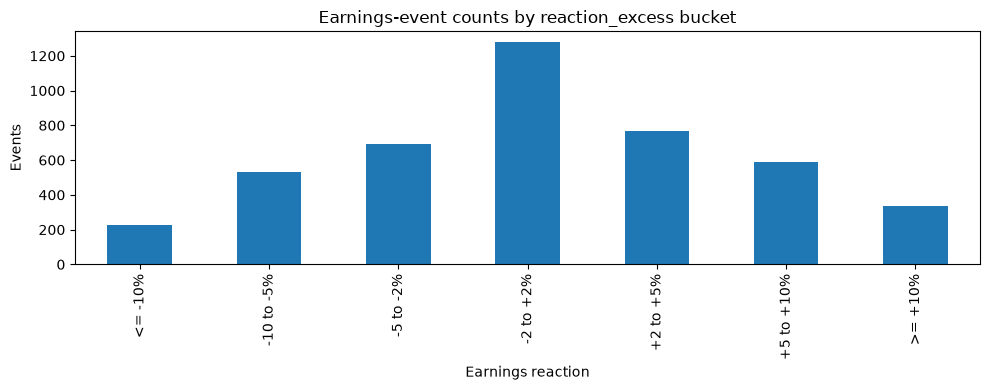

In [17]:
BUCKET_EDGES = [-np.inf, -0.10, -0.05, -0.02, 0.02, 0.05, 0.10, np.inf]
BUCKET_LABELS = ["<= -10%", "-10 to -5%", "-5 to -2%", "-2 to +2%", "+2 to +5%", "+5 to +10%", ">= +10%"]

events["reaction_bucket"] = pd.cut(
    events[PRIMARY_REACTION], bins=BUCKET_EDGES, labels=BUCKET_LABELS,
    right=False, include_lowest=True
)

bucket_counts = events["reaction_bucket"].value_counts(sort=False).rename("events").to_frame()
bucket_counts["tickers"] = events.groupby("reaction_bucket", observed=False)["ticker"].nunique()
display(bucket_counts)

ax = bucket_counts["events"].plot(kind="bar", figsize=(10, 4), title=f"Earnings-event counts by {PRIMARY_REACTION} bucket")
ax.set_xlabel("Earnings reaction")
ax.set_ylabel("Events")
plt.tight_layout()
plt.show()

## 9. Bucketed forward returns: raw vs SPY vs market-model abnormal

The most useful columns here are:

- `mean_excess` / `median_excess`: event-matched performance relative to SPY;
- `ticker_equal_mean_excess`: first average within each company, then average across companies so a ticker with more observations cannot dominate;
- `mean_mm_car`: market-model abnormal return after adjusting for estimated beta.

In [18]:
def bucket_summary(events):
    rows = []
    for bucket in BUCKET_LABELS:
        sub = events[events["reaction_bucket"].astype(str).eq(bucket)]
        for label in HORIZONS:
            ex = sub[f"excess_{label}"].dropna()
            mm = sub[f"mm_car_{label}"].dropna()
            raw = sub[f"stock_{label}"].dropna()
            spy = sub[f"spy_{label}"].dropna()

            ticker_means = sub.groupby("ticker")[f"excess_{label}"].mean().dropna()
            rows.append({
                "bucket": bucket,
                "horizon": label,
                "n_events": len(ex),
                "n_tickers": sub.loc[ex.index, "ticker"].nunique() if len(ex) else 0,
                "mean_stock": raw.mean(),
                "mean_spy": spy.mean(),
                "mean_excess": ex.mean(),
                "median_excess": ex.median(),
                "ticker_equal_mean_excess": ticker_means.mean(),
                "positive_excess_rate": (ex > 0).mean(),
                "mean_mm_car": mm.mean(),
                "median_mm_car": mm.median(),
            })
    return pd.DataFrame(rows)


bucket_stats = bucket_summary(events)
display(bucket_stats)

,bucket,horizon,n_events,n_tickers,mean_stock,mean_spy,mean_excess,median_excess,ticker_equal_mean_excess,positive_excess_rate,mean_mm_car,median_mm_car
0,<= -10%,1w,227,71,0.006148,0.005813,-0.000203,-0.008921,0.005395,0.427313,-0.004046,-0.008764
1,<= -10%,1m,226,71,0.015704,0.008658,0.006318,-0.004194,0.015882,0.477876,-0.003866,-0.007269
2,<= -10%,3m,216,69,0.070118,0.030625,0.034790,0.033558,0.043116,0.560185,0.004985,0.015193
3,<= -10%,6m,207,69,0.164819,0.062627,0.090146,0.048100,0.092542,0.570048,0.024409,0.016307
4,<= -10%,1y,194,67,0.389774,0.139869,0.213613,0.092101,0.214727,0.582474,0.063592,0.016186
5,-10 to -5%,1w,532,94,0.001790,0.004078,-0.002419,-0.005189,0.001330,0.422932,-0.006113,-0.007058
6,-10 to -5%,1m,531,94,0.015225,0.012082,0.002997,-0.003437,0.007977,0.461394,-0.009252,-0.014044
7,-10 to -5%,3m,511,93,0.048659,0.038407,0.009632,0.003459,0.001824,0.514677,-0.023902,-0.013496
8,-10 to -5%,6m,499,93,0.118148,0.077064,0.036739,0.007784,0.040955,0.513026,-0.042012,-0.035702
9,-10 to -5%,1y,471,92,0.305418,0.150312,0.129259,0.046704,0.109232,0.581741,-0.025977,-0.034853


### Heatmap-style view: mean SPY-adjusted forward return

This is intentionally based on excess return rather than raw stock return.

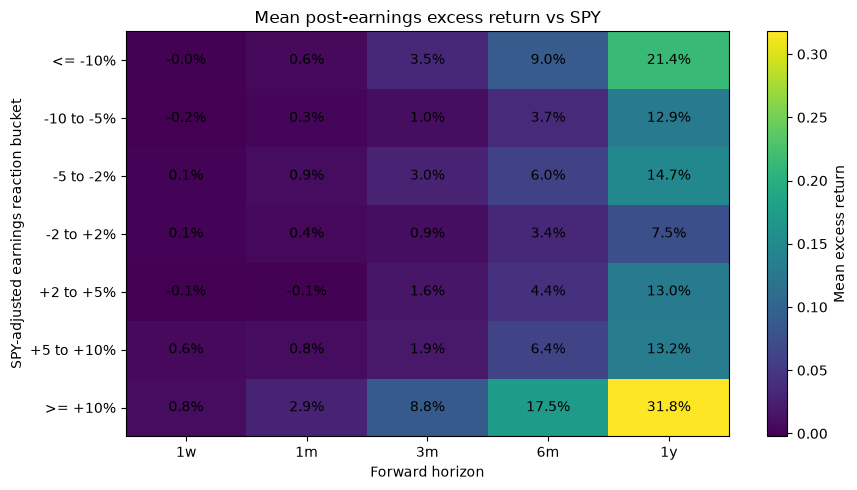

In [19]:
heat = bucket_stats.pivot(index="bucket", columns="horizon", values="mean_excess")
heat = heat.reindex(index=BUCKET_LABELS, columns=list(HORIZONS))

fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(heat.to_numpy(), aspect="auto")
ax.set_xticks(range(len(heat.columns)), heat.columns)
ax.set_yticks(range(len(heat.index)), heat.index)
ax.set_xlabel("Forward horizon")
ax.set_ylabel("SPY-adjusted earnings reaction bucket")
ax.set_title("Mean post-earnings excess return vs SPY")

for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        v = heat.iloc[i, j]
        ax.text(j, i, "" if pd.isna(v) else f"{v:.1%}", ha="center", va="center")

fig.colorbar(im, ax=ax, label="Mean excess return")
plt.tight_layout()
plt.show()

## 10. Threshold analysis: big drops vs big jumps

This directly answers the video question at fixed cutoffs such as ±5% and ±10%.

The confidence interval uses a **ticker-cluster bootstrap**: it resamples companies, carrying each sampled company's events with it. That is more defensible than pretending every quarterly event is fully independent.

In [20]:
def cluster_bootstrap_mean(df, value_col, n_boot=1000, seed=RANDOM_SEED):
    clean = df[["ticker", value_col]].dropna()
    tickers_here = clean["ticker"].unique()
    if len(tickers_here) < 2:
        return np.nan, np.nan

    groups = {t: clean.loc[clean["ticker"].eq(t), value_col].to_numpy() for t in tickers_here}
    rng = np.random.default_rng(seed)
    means = np.empty(n_boot)

    for i in range(n_boot):
        sampled = rng.choice(tickers_here, size=len(tickers_here), replace=True)
        vals = np.concatenate([groups[t] for t in sampled])
        means[i] = np.nanmean(vals)

    return np.quantile(means, [0.025, 0.975])


def bh_fdr(pvals):
    p = np.asarray(pvals, dtype=float)
    out = np.full(len(p), np.nan)
    valid = np.isfinite(p)
    pv = p[valid]
    if not len(pv):
        return out

    order = np.argsort(pv)
    ranked = pv[order]
    q = ranked * len(ranked) / np.arange(1, len(ranked) + 1)
    q = np.minimum.accumulate(q[::-1])[::-1]
    q = np.clip(q, 0, 1)

    unorder = np.empty_like(q)
    unorder[order] = q
    out[np.where(valid)[0]] = unorder
    return out


def threshold_summary(events, reaction_col=PRIMARY_REACTION, n_boot=1000):
    rows = []
    for threshold in THRESHOLDS:
        for side in ["down", "up"]:
            mask = events[reaction_col].le(-threshold) if side == "down" else events[reaction_col].ge(threshold)
            selected = events.loc[mask]

            for label in HORIZONS:
                value_col = f"excess_{label}"
                vals = selected[value_col].dropna()
                ticker_means = selected.groupby("ticker")[value_col].mean().dropna()

                if len(vals) >= 2:
                    t_stat, p_value = stats.ttest_1samp(vals, 0, nan_policy="omit")
                    ci_low, ci_high = cluster_bootstrap_mean(selected, value_col, n_boot=n_boot)
                else:
                    t_stat = p_value = ci_low = ci_high = np.nan

                mm = selected[f"mm_car_{label}"].dropna()
                rows.append({
                    "threshold": threshold,
                    "side": side,
                    "horizon": label,
                    "n_events": len(vals),
                    "n_tickers": selected.loc[vals.index, "ticker"].nunique() if len(vals) else 0,
                    "mean_excess": vals.mean(),
                    "median_excess": vals.median(),
                    "ticker_equal_mean_excess": ticker_means.mean(),
                    "positive_excess_rate": (vals > 0).mean(),
                    "cluster_ci_low": ci_low,
                    "cluster_ci_high": ci_high,
                    "mean_mm_car": mm.mean(),
                    "t_stat_naive": t_stat,
                    "p_value_naive": p_value,
                })

    out = pd.DataFrame(rows)
    out["q_value_bh"] = bh_fdr(out["p_value_naive"])
    return out


threshold_stats = threshold_summary(events)
display(threshold_stats)

,threshold,side,horizon,n_events,n_tickers,mean_excess,median_excess,ticker_equal_mean_excess,positive_excess_rate,cluster_ci_low,cluster_ci_high,mean_mm_car,t_stat_naive,p_value_naive,q_value_bh
0,0.02,down,1w,1450,100,-0.000520,-0.003085,0.004237,0.463448,-0.003024,0.002070,-0.003872,-0.379313,7.045111e-01,7.225755e-01
1,0.02,down,1m,1444,100,0.006162,-0.002246,0.016631,0.482687,0.001542,0.011109,-0.006261,2.456345,1.415294e-02,2.021849e-02
2,0.02,down,3m,1404,98,0.023141,0.007596,0.064007,0.526353,0.012197,0.034248,-0.013831,4.054693,5.295875e-05,1.114921e-04
3,0.02,down,6m,1362,98,0.056068,0.015245,0.174378,0.534508,0.033821,0.081206,-0.024724,5.004673,6.326958e-07,2.108986e-06
4,0.02,down,1y,1293,97,0.150390,0.042811,0.430928,0.566899,0.102897,0.213266,-0.023130,5.640645,2.079046e-08,8.316185e-08
5,0.02,up,1w,1696,98,0.002841,0.001073,0.001699,0.510024,0.000407,0.005344,0.000625,2.185373,2.899801e-02,3.624751e-02
6,0.02,up,1m,1691,98,0.008155,0.005149,0.008047,0.532821,0.003754,0.012565,-0.000049,3.631309,2.903968e-04,5.531367e-04
7,0.02,up,3m,1661,97,0.031399,0.012721,0.037113,0.542444,0.021014,0.042328,0.006391,7.082274,2.086516e-12,2.086516e-11
8,0.02,up,6m,1624,97,0.075562,0.031330,0.106119,0.567118,0.053352,0.098842,0.014702,8.664141,1.080033e-17,4.320131e-16
9,0.02,up,1y,1546,97,0.166172,0.060942,0.473575,0.606727,0.111655,0.228726,0.014167,6.608697,5.322087e-11,3.548058e-10


### Plot threshold curves

If the effect is real rather than one lucky cutoff, you would prefer to see some **dose-response consistency** as the reaction threshold becomes more extreme.

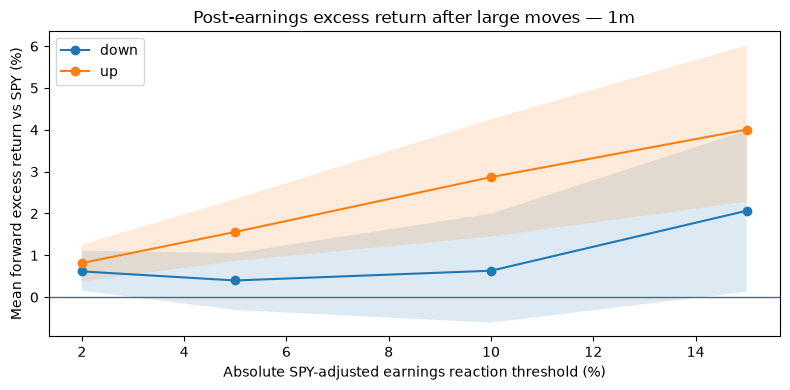

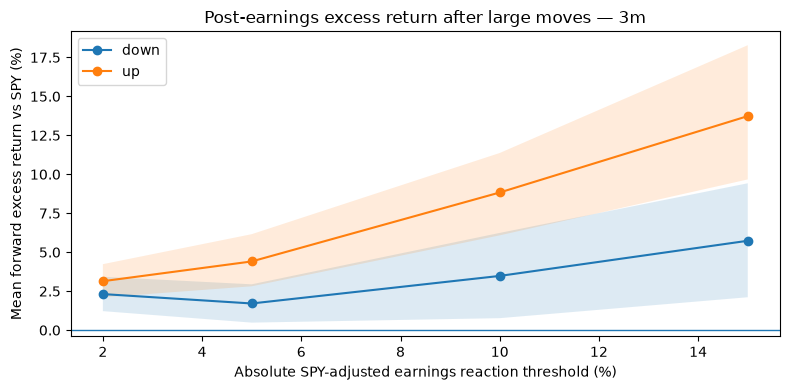

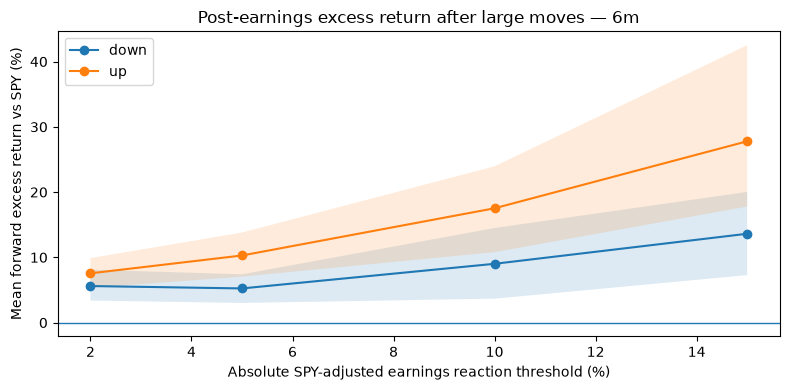

In [21]:
for horizon in ["1m", "3m", "6m"]:
    fig, ax = plt.subplots(figsize=(8, 4))
    sub = threshold_stats[threshold_stats["horizon"].eq(horizon)]

    for side in ["down", "up"]:
        s = sub[sub["side"].eq(side)].sort_values("threshold")
        ax.plot(s["threshold"] * 100, s["mean_excess"] * 100, marker="o", label=side)
        ax.fill_between(
            s["threshold"] * 100,
            s["cluster_ci_low"] * 100,
            s["cluster_ci_high"] * 100,
            alpha=0.15,
        )

    ax.axhline(0, linewidth=1)
    ax.set_xlabel("Absolute SPY-adjusted earnings reaction threshold (%)")
    ax.set_ylabel("Mean forward excess return vs SPY (%)")
    ax.set_title(f"Post-earnings excess return after large moves — {horizon}")
    ax.legend()
    plt.tight_layout()
    plt.show()

## 11. Compare against a neutral earnings reaction

A zero-centered comparison is useful because "positive excess return after earnings" alone does not establish that a large reaction contains information. Here the neutral group is the pre-specified **−2% to +2% SPY-adjusted reaction** bucket.

In [22]:
def vs_neutral_summary(events):
    neutral = events[events[PRIMARY_REACTION].between(-0.02, 0.02, inclusive="left")]
    rows = []

    for threshold in THRESHOLDS:
        for side in ["down", "up"]:
            mask = events[PRIMARY_REACTION].le(-threshold) if side == "down" else events[PRIMARY_REACTION].ge(threshold)
            selected = events.loc[mask]

            for label in HORIZONS:
                a = selected[f"excess_{label}"].dropna()
                b = neutral[f"excess_{label}"].dropna()
                if len(a) >= 2 and len(b) >= 2:
                    stat, p = stats.ttest_ind(a, b, equal_var=False, nan_policy="omit")
                else:
                    stat = p = np.nan

                rows.append({
                    "threshold": threshold,
                    "side": side,
                    "horizon": label,
                    "signal_mean": a.mean(),
                    "neutral_mean": b.mean(),
                    "difference": a.mean() - b.mean(),
                    "welch_t": stat,
                    "p_value": p,
                    "signal_n": len(a),
                    "neutral_n": len(b),
                })

    out = pd.DataFrame(rows)
    out["q_value_bh"] = bh_fdr(out["p_value"])
    return out


vs_neutral = vs_neutral_summary(events)
display(vs_neutral)

,threshold,side,horizon,signal_mean,neutral_mean,difference,welch_t,p_value,signal_n,neutral_n,q_value_bh
0,0.02,down,1w,-0.000520,0.000746,-0.001266,-0.682687,4.948626e-01,1450,1277,0.565557
1,0.02,down,1m,0.006162,0.003892,0.002270,0.640049,5.221947e-01,1444,1276,0.580216
2,0.02,down,3m,0.023141,0.009009,0.014132,2.014730,4.404061e-02,1404,1262,0.076592
3,0.02,down,6m,0.056068,0.034437,0.021631,1.662722,9.651161e-02,1362,1245,0.148479
4,0.02,down,1y,0.150390,0.075395,0.074994,2.559032,1.057747e-02,1293,1194,0.022653
5,0.02,up,1w,0.002841,0.000746,0.002095,1.162062,2.453048e-01,1696,1277,0.306631
6,0.02,up,1m,0.008155,0.003892,0.004264,1.266605,2.054023e-01,1691,1276,0.265035
7,0.02,up,3m,0.031399,0.009009,0.022390,3.716937,2.054478e-04,1661,1262,0.000747
8,0.02,up,6m,0.075562,0.034437,0.041125,3.757321,1.752292e-04,1624,1245,0.000701
9,0.02,up,1y,0.166172,0.075395,0.090777,3.249872,1.172003e-03,1546,1194,0.003606


## 12. Calendar-time portfolio backtest

Event averages can still be misleading. This section asks a more practical question:

> If I entered after every qualifying earnings reaction and held each signal for a fixed number of trading days, what would an equal-weight portfolio have done?

Rules:

- signals are based on the **SPY-adjusted earnings reaction** by default;
- entry occurs only after the reaction is observable;
- active tickers are equally weighted each day;
- when no signals are active, the strategy is in cash;
- the matched SPY benchmark is also invested only on days when the strategy has exposure;
- simple turnover-based transaction costs are charged to both strategy and matched benchmark.

This is still a simplified research backtest, but it is much harder to fool yourself with than averaging raw post-event stock returns.

In [23]:
def perf_metrics(returns):
    r = pd.Series(returns).fillna(0.0)
    if len(r) == 0:
        return {k: np.nan for k in ["total_return", "cagr", "ann_vol", "sharpe_0rf", "max_drawdown"]}

    wealth = (1 + r).cumprod()
    years = len(r) / 252
    cagr = wealth.iloc[-1] ** (1 / years) - 1 if years > 0 and wealth.iloc[-1] > 0 else np.nan
    ann_vol = r.std(ddof=1) * np.sqrt(252)
    sharpe = r.mean() / r.std(ddof=1) * np.sqrt(252) if r.std(ddof=1) > 0 else np.nan
    drawdown = wealth / wealth.cummax() - 1

    return {
        "total_return": wealth.iloc[-1] - 1,
        "cagr": cagr,
        "ann_vol": ann_vol,
        "sharpe_0rf": sharpe,
        "max_drawdown": drawdown.min(),
    }


def calendar_time_backtest(events, prices, threshold=0.05, side="up", hold_days=63, reaction_col=PRIMARY_REACTION):
    sessions = pd.DatetimeIndex(prices.index)
    rets = prices.pct_change()
    selected = events[
        events[reaction_col].ge(threshold) if side == "up" else events[reaction_col].le(-threshold)
    ].copy()

    active = defaultdict(set)
    for row in selected.itertuples():
        entry = pd.Timestamp(row.entry_date)
        if entry not in sessions:
            continue
        entry_pos = sessions.get_loc(entry)
        for pos in range(entry_pos + 1, min(entry_pos + hold_days + 1, len(sessions))):
            active[sessions[pos]].add(row.ticker)

    target_weights = {}
    for d in sessions:
        names = sorted(active.get(d, set()))
        if names:
            w = 1 / len(names)
            target_weights[d] = {t: w for t in names}
        else:
            target_weights[d] = {}

    cost_rate = TRADING_COST_BPS_PER_SIDE / 10000
    strategy = pd.Series(0.0, index=sessions, name="strategy")
    matched_spy = pd.Series(0.0, index=sessions, name="matched_spy")
    turnover = pd.Series(0.0, index=sessions, name="turnover")
    active_count = pd.Series(0, index=sessions, name="active_positions")

    prev_w = {}
    prev_spy_w = 0.0

    for d in sessions[1:]:
        w = target_weights[d]
        active_count.loc[d] = len(w)

        gross = sum(weight * rets.at[d, t] for t, weight in w.items() if t in rets.columns and pd.notna(rets.at[d, t]))
        spy_w = 1.0 if w else 0.0
        spy_gross = spy_w * (rets.at[d, BENCHMARK] if pd.notna(rets.at[d, BENCHMARK]) else 0.0)

        all_names = set(prev_w) | set(w)
        one_way_turnover = 0.5 * sum(abs(w.get(t, 0.0) - prev_w.get(t, 0.0)) for t in all_names)
        # Include movement between cash and risky assets.
        cash_prev = 1 - sum(prev_w.values())
        cash_now = 1 - sum(w.values())
        one_way_turnover += 0.5 * abs(cash_now - cash_prev)

        spy_turnover = abs(spy_w - prev_spy_w)

        strategy.loc[d] = gross - one_way_turnover * cost_rate
        matched_spy.loc[d] = spy_gross - spy_turnover * cost_rate
        turnover.loc[d] = one_way_turnover

        prev_w = w
        prev_spy_w = spy_w

    first_signal = selected["entry_date"].min() if len(selected) else sessions[0]
    bt = pd.concat([strategy, matched_spy, turnover, active_count], axis=1).loc[first_signal:]

    summary = pd.DataFrame({
        "strategy": perf_metrics(bt["strategy"]),
        "matched_spy": perf_metrics(bt["matched_spy"]),
    })
    summary.loc["active_day_fraction", "strategy"] = (bt["active_positions"] > 0).mean()
    summary.loc["event_count", "strategy"] = len(selected)
    summary.loc["unique_tickers", "strategy"] = selected["ticker"].nunique()
    summary.loc["avg_daily_turnover", "strategy"] = bt["turnover"].mean()

    return bt, summary, selected


DOWN >= 5% absolute reaction | hold 63 trading days


,strategy,matched_spy
total_return,12.177203,4.144767
cagr,0.225843,0.138094
ann_vol,0.249872,0.171437
sharpe_0rf,0.940168,0.840646
max_drawdown,-0.363132,-0.337173
active_day_fraction,0.999687,NaN
event_count,759.000000,NaN
unique_tickers,98.000000,NaN
avg_daily_turnover,0.024248,NaN


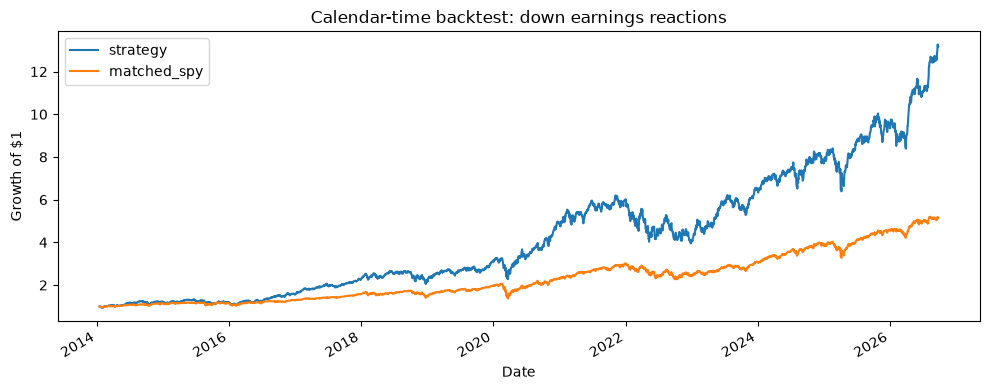


UP >= 5% absolute reaction | hold 63 trading days


,strategy,matched_spy
total_return,34.841185,4.170010
cagr,0.325936,0.138257
ann_vol,0.255443,0.171351
sharpe_0rf,1.233279,0.841817
max_drawdown,-0.461705,-0.337173
active_day_fraction,0.999687,NaN
event_count,927.000000,NaN
unique_tickers,97.000000,NaN
avg_daily_turnover,0.024485,NaN


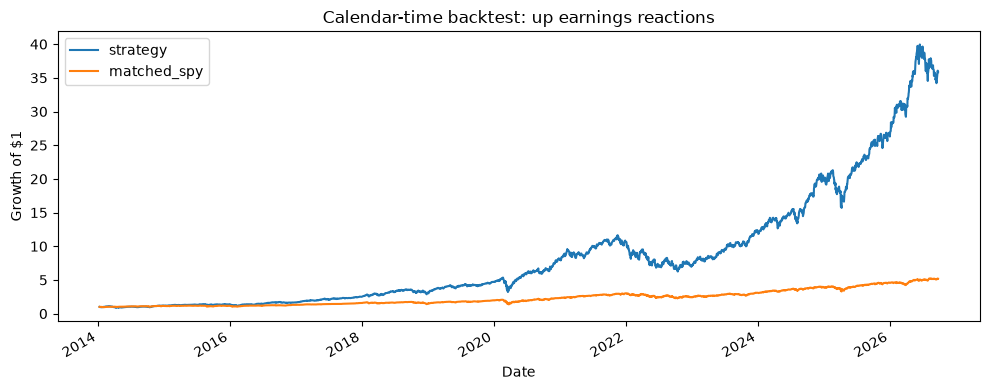

In [24]:
for side in ["down", "up"]:
    bt, summary, selected = calendar_time_backtest(
        events, prices,
        threshold=BACKTEST_THRESHOLD,
        side=side,
        hold_days=BACKTEST_HOLD_DAYS,
    )

    print(f"\n{side.upper()} >= {BACKTEST_THRESHOLD:.0%} absolute reaction | hold {BACKTEST_HOLD_DAYS} trading days")
    display(summary)

    wealth = (1 + bt[["strategy", "matched_spy"]]).cumprod()
    ax = wealth.plot(figsize=(10, 4), title=f"Calendar-time backtest: {side} earnings reactions")
    ax.set_ylabel("Growth of $1")
    plt.tight_layout()
    plt.show()

## 13. Robustness: raw reaction vs SPY-adjusted reaction vs market-model event CAR

If a pattern exists only under one arbitrary definition of "big earnings move," be skeptical. This cell lets you compare the same fixed threshold analysis using three event definitions.

In [25]:
robustness = []
for reaction_col in ["reaction_raw", "reaction_excess", "reaction_mm_car"]:
    tmp = threshold_summary(events, reaction_col=reaction_col, n_boot=500)
    tmp.insert(0, "reaction_definition", reaction_col)
    robustness.append(tmp)

robustness_stats = pd.concat(robustness, ignore_index=True)
display(robustness_stats)

,reaction_definition,threshold,side,horizon,n_events,n_tickers,mean_excess,median_excess,ticker_equal_mean_excess,positive_excess_rate,cluster_ci_low,cluster_ci_high,mean_mm_car,t_stat_naive,p_value_naive,q_value_bh
0,reaction_raw,0.02,down,1w,1455,100,-0.001176,-0.003800,0.003504,0.457732,-0.003623,0.001182,-0.004347,-0.850031,3.954479e-01,4.162609e-01
1,reaction_raw,0.02,down,1m,1449,100,0.005968,-0.001421,0.014639,0.487923,0.001407,0.010988,-0.005841,2.412176,1.598131e-02,2.090212e-02
2,reaction_raw,0.02,down,3m,1410,98,0.023026,0.008189,0.063629,0.530496,0.012196,0.035093,-0.012143,4.090489,4.548347e-05,9.096693e-05
3,reaction_raw,0.02,down,6m,1372,98,0.055877,0.014116,0.173618,0.534985,0.034784,0.083695,-0.023262,5.026348,5.658888e-07,1.741196e-06
4,reaction_raw,0.02,down,1y,1300,97,0.150216,0.043014,0.430628,0.569231,0.103040,0.218732,-0.020306,5.677021,1.688780e-08,6.755120e-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,reaction_mm_car,0.15,up,1w,115,42,0.015296,0.009477,0.011109,0.556522,0.005297,0.025402,0.011552,2.299130,2.331903e-02,3.008907e-02
116,reaction_mm_car,0.15,up,1m,114,42,0.041139,0.031287,0.042188,0.631579,0.024014,0.062682,0.023795,3.180298,1.899190e-03,3.038704e-03
117,reaction_mm_car,0.15,up,3m,109,40,0.136667,0.095784,0.136288,0.651376,0.090856,0.189687,0.065066,4.389878,2.653077e-05,6.242534e-05
118,reaction_mm_car,0.15,up,6m,102,37,0.235644,0.138279,0.228852,0.676471,0.138252,0.344738,0.095133,4.719685,7.617239e-06,2.031264e-05


## 14. Per-ticker results

This is a useful defense against a result being driven by a handful of famous names. The table below shows ticker-level average excess returns after ±5% SPY-adjusted earnings moves.

In [26]:
def per_ticker_signal_summary(events, threshold=0.05, horizon="3m"):
    rows = []
    for side in ["down", "up"]:
        mask = events[PRIMARY_REACTION].le(-threshold) if side == "down" else events[PRIMARY_REACTION].ge(threshold)
        sub = events.loc[mask]
        g = sub.groupby("ticker").agg(
            events=("ticker", "size"),
            mean_reaction=(PRIMARY_REACTION, "mean"),
            mean_excess=(f"excess_{horizon}", "mean"),
            median_excess=(f"excess_{horizon}", "median"),
        ).reset_index()
        g.insert(1, "side", side)
        rows.append(g)
    return pd.concat(rows, ignore_index=True)


per_ticker = per_ticker_signal_summary(events)
display(per_ticker.sort_values(["side", "mean_excess"]))

,ticker,side,events,mean_reaction,mean_excess,median_excess
63,NBIS,down,1,-0.072428,-0.122551,-0.122551
89,TRI,down,4,-0.080167,-0.104961,-0.102722
13,APP,down,4,-0.146166,-0.101367,0.049362
64,NFLX,down,19,-0.108799,-0.081589,-0.089764
20,CCEP,down,2,-0.083199,-0.075485,-0.075485
...,...,...,...,...,...,...
147,LITE,up,15,0.118038,0.273607,0.121728
192,WDC,up,8,0.080403,0.315263,0.210601
160,NBIS,up,4,0.183218,0.464339,0.554842
180,SNDK,up,3,0.101059,0.729369,0.972506


## 15. Export analysis tables

This writes the event-level dataset and summary tables to CSV so plots / slides can be made without rerunning data collection.

In [ ]:
OUTPUT_DIR = Path("results")
OUTPUT_DIR.mkdir(exist_ok=True)

events.to_csv(OUTPUT_DIR / "earnings_events.csv", index=False)
bucket_stats.to_csv(OUTPUT_DIR / "bucket_summary.csv", index=False)
threshold_stats.to_csv(OUTPUT_DIR / "threshold_summary.csv", index=False)
vs_neutral.to_csv(OUTPUT_DIR / "vs_neutral_summary.csv", index=False)
robustness_stats.to_csv(OUTPUT_DIR / "robustness_summary.csv", index=False)
per_ticker.to_csv(OUTPUT_DIR / "per_ticker_summary.csv", index=False)

print(f"Saved outputs to: {OUTPUT_DIR.resolve()}")